# 02 — Temporal Feature Analysis
**Spotify Dataset 1921–2020** · ~600k tracks · Source: [Kaggle](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks)

### Purpose
How did music change over a century? This notebook tracks the evolution of  
audio features from 1921 to 2020, revealing long-term production trends,  
structural inflection points, and the mechanisms behind them.

### Sections
| # | Section |
|---|---------|
| 1 | Load & setup |
| 2 | Feature trends overview (all features) |
| 3 | The Loudness War — scatter analysis |
| 4 | Valence — the emotional anomaly |
| 5 | Mode distribution over time |
| 6 | Key distribution by decade |
| 7 | Findings |


## 0 · Imports & Configuration

In [35]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from shared.config    import PATHS, PALETTE, FEATURES, ERAS, set_style
from shared.plot_utils import shade_eras, era_legend, make_fig, temporal_lineplot, get_era

set_style()

---
## 1 · Load & Setup

In [36]:
# [STEP 1] - Load clean dataset
tracks_clean = pd.read_parquet(PATHS['clean'])

print(f"Shape : {tracks_clean.shape}")
print(f"Year range: {tracks_clean['year'].min()} - {tracks_clean['year'].max()}")

Shape : (569604, 28)
Year range: 1922 – 2021


In [37]:
# [STEP 2] - Compute yearly means (track-level granularity)
#            Note: correlations computed on yearly means risk ecological fallacy
#            (see Section 3 and clustering notebook). Yearly means are used here
#            only for visualization, not for inferring track-level relationships.

yearly_means = tracks_clean.groupby('year')[FEATURES['all']].mean()

yearly_means.head()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,loudness,tempo,duration_min
year,,,,,,,,,,
1922,0.896477,0.538211,0.325625,0.310462,0.252583,0.252422,0.564326,-13.784088,108.086298,2.778163
1923,0.858077,0.640411,0.266250,0.151017,0.224340,0.558804,0.671461,-16.358369,108.411788,2.612002
1924,0.861476,0.602447,0.359599,0.321441,0.205169,0.387743,0.554438,-13.204967,117.629066,3.085950
1925,0.925219,0.629159,0.265597,0.272965,0.259307,0.314233,0.641863,-14.349965,113.576160,3.192260
1926,0.779537,0.627544,0.261137,0.313735,0.213979,0.364861,0.532783,-15.979094,110.831847,2.760433


---
## 2 · Feature Trends Overview

One line plot per feature, with era shading.  
The goal is a first visual scan of the century-long trends before zooming in.

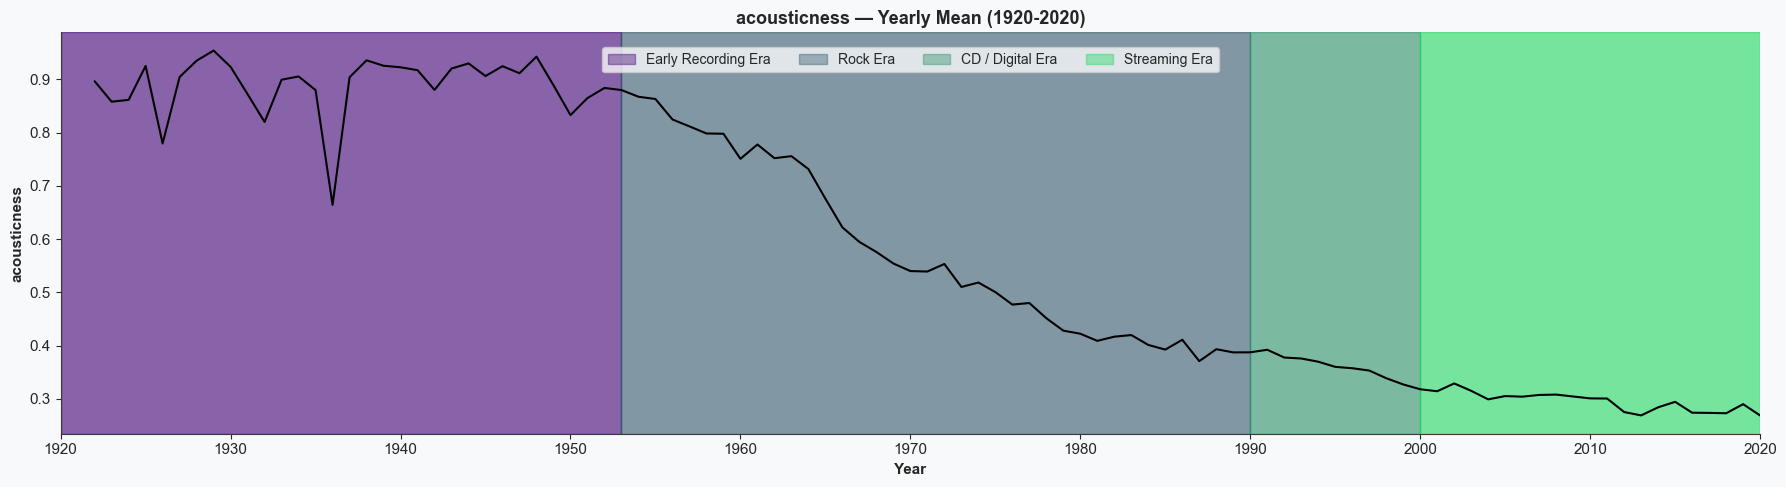

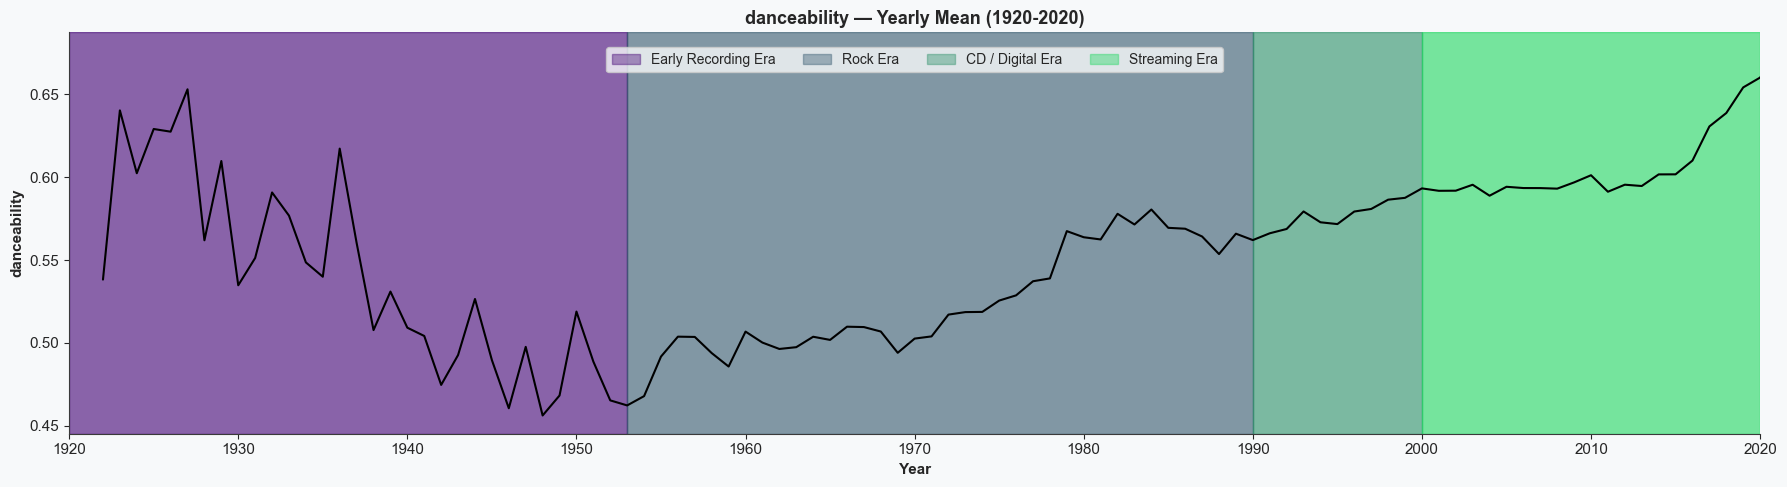

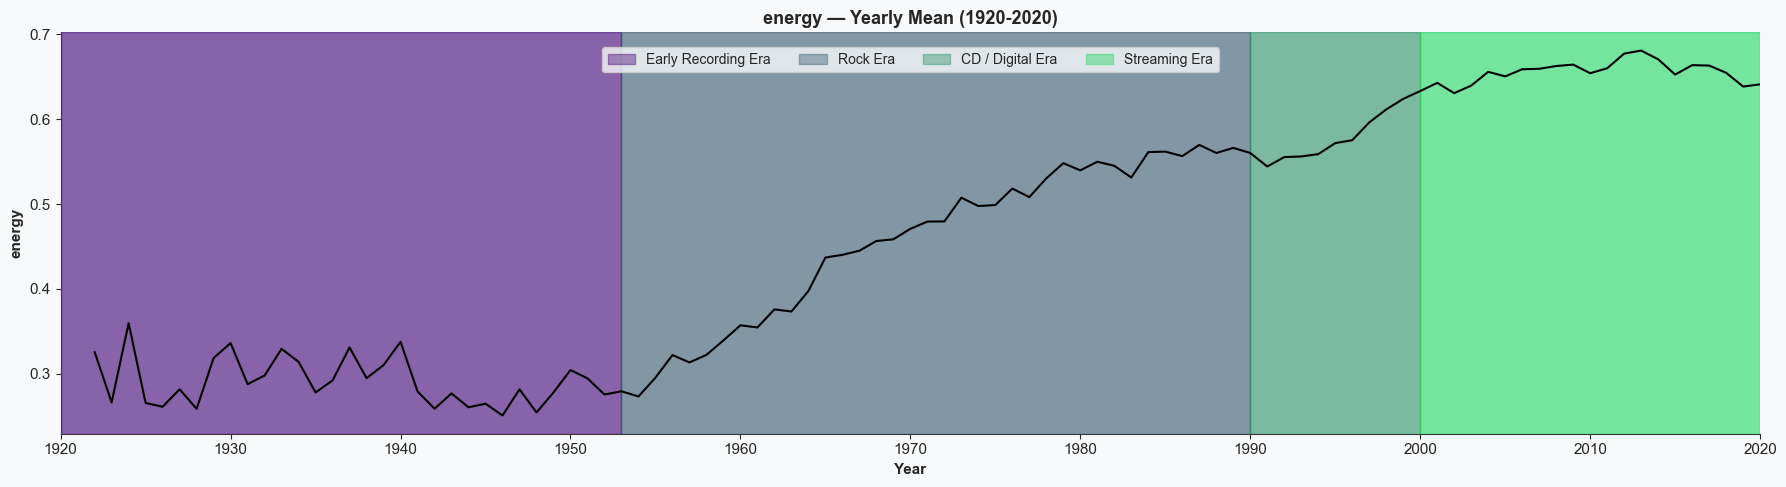

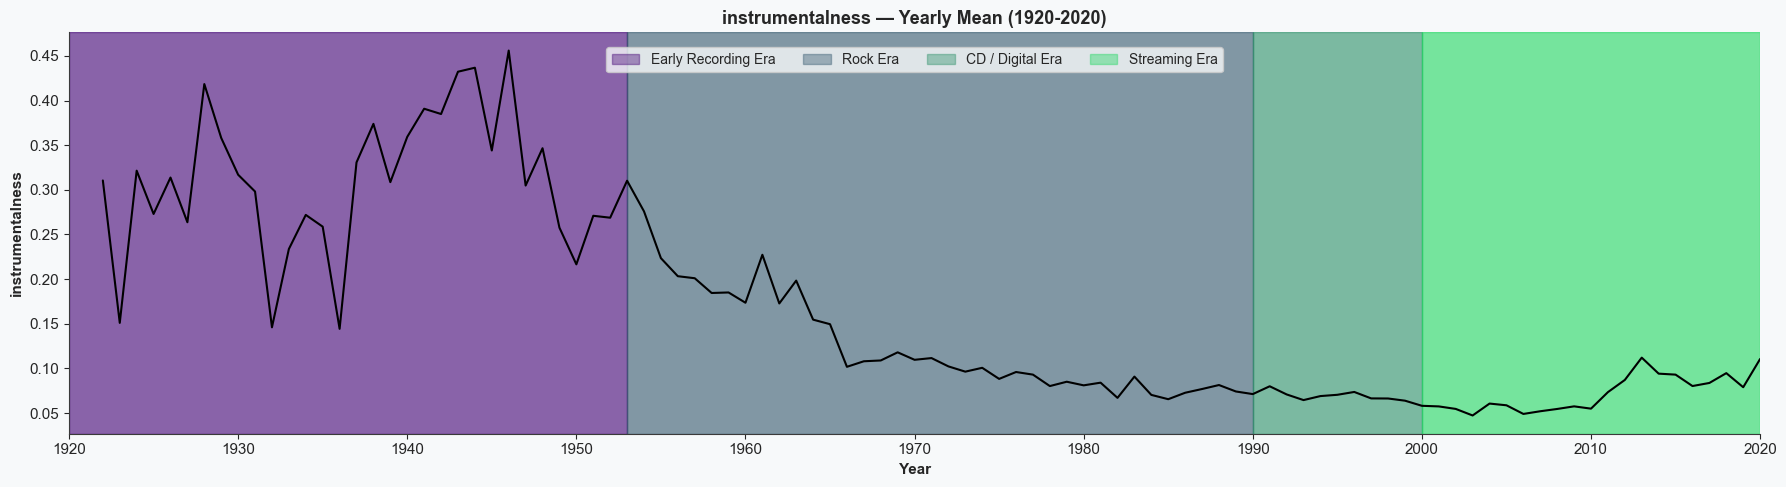

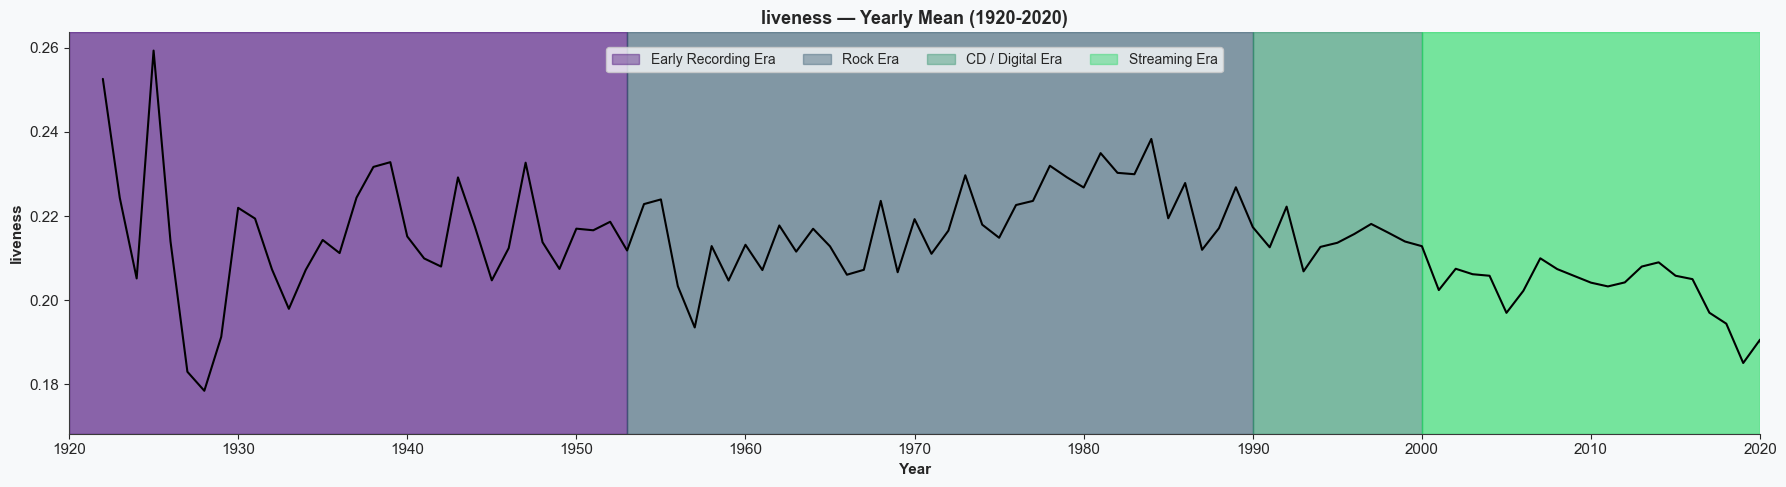

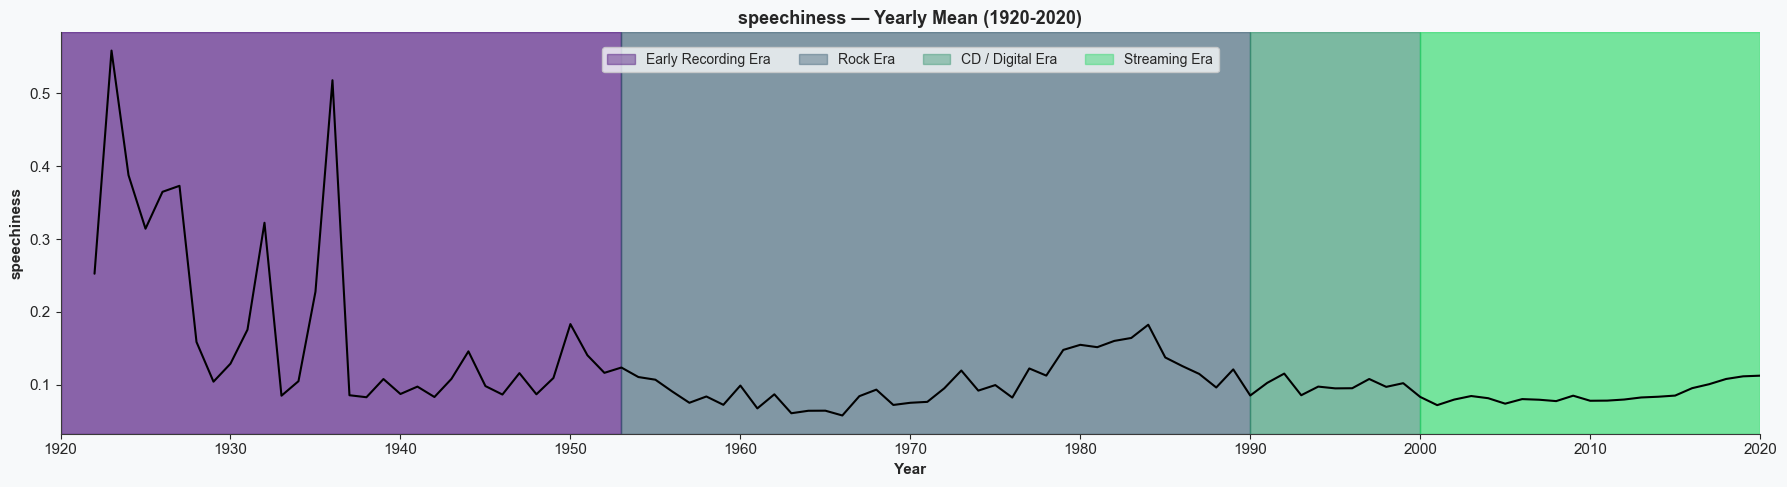

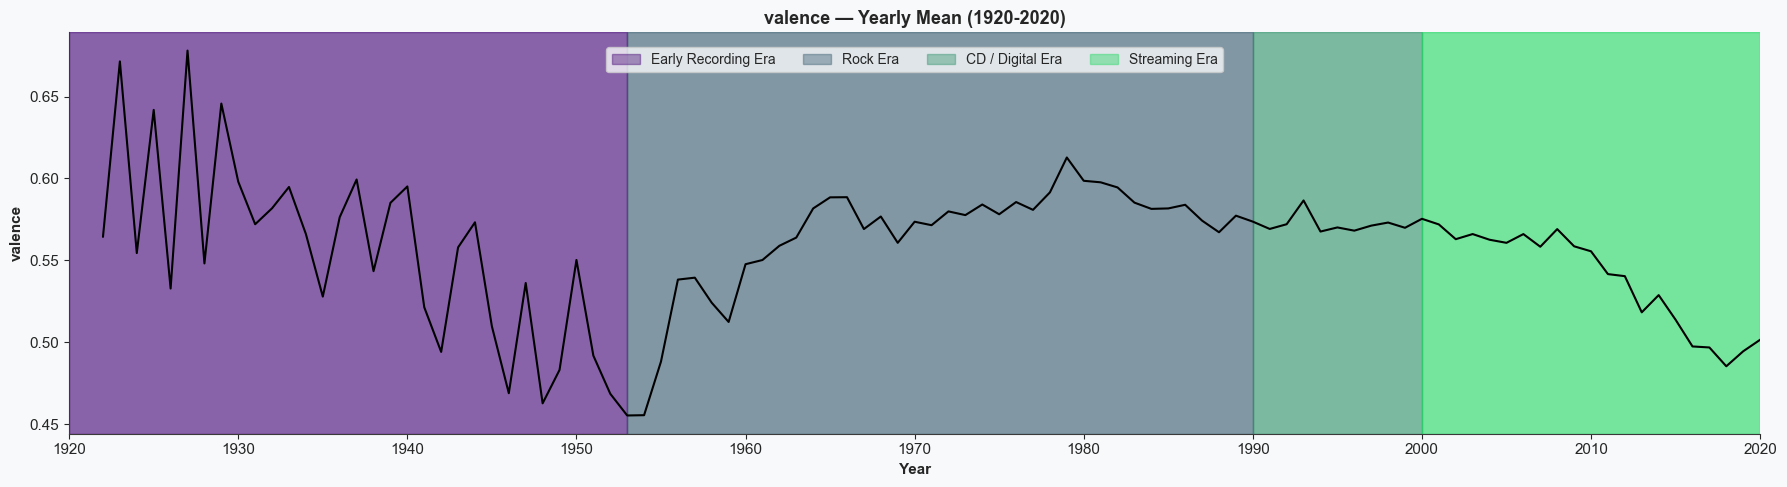

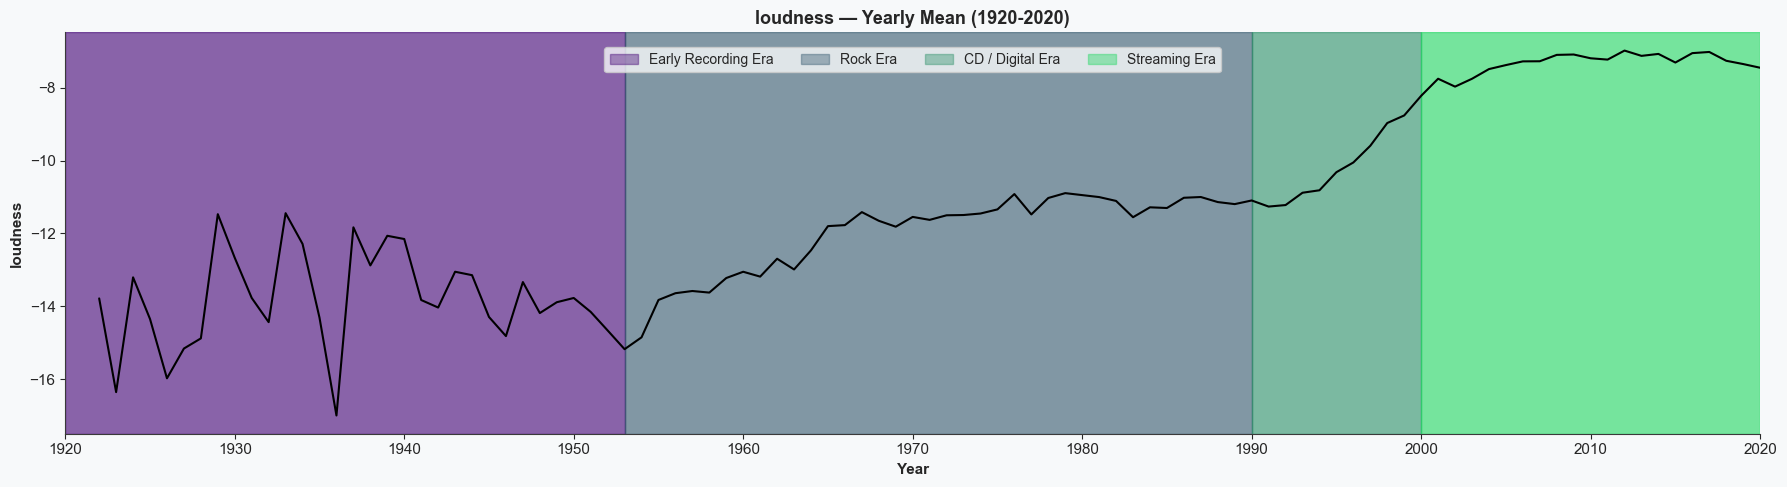

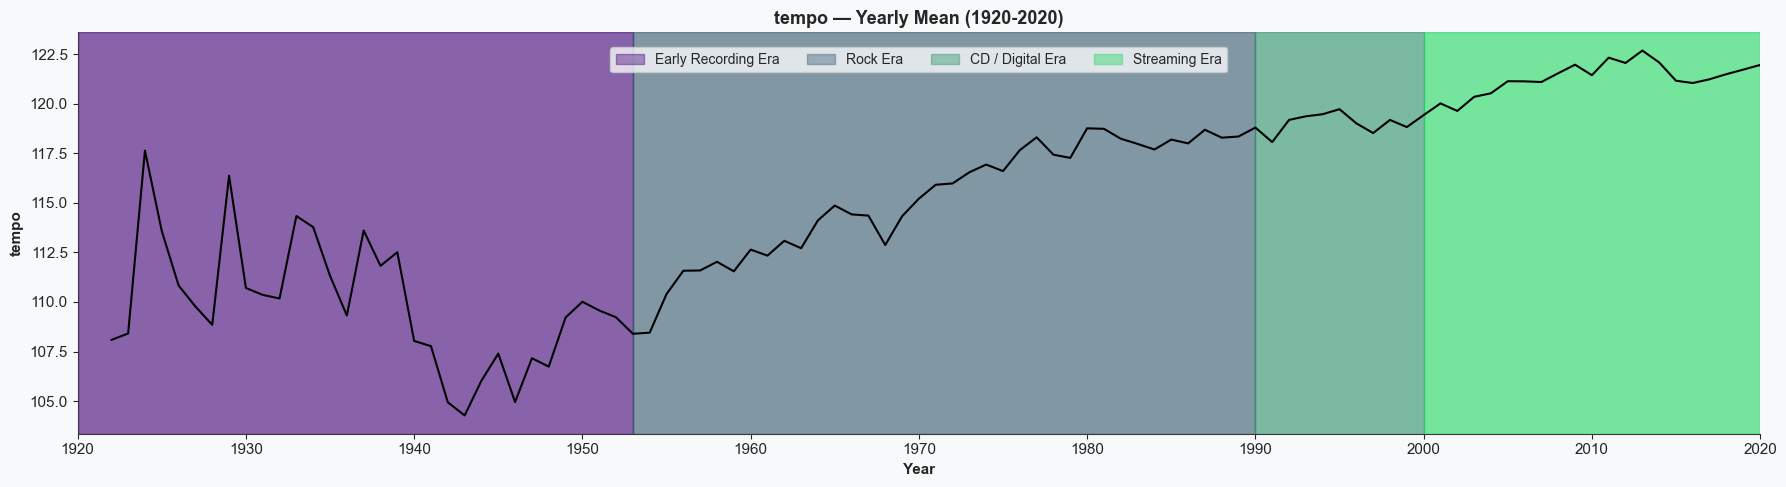

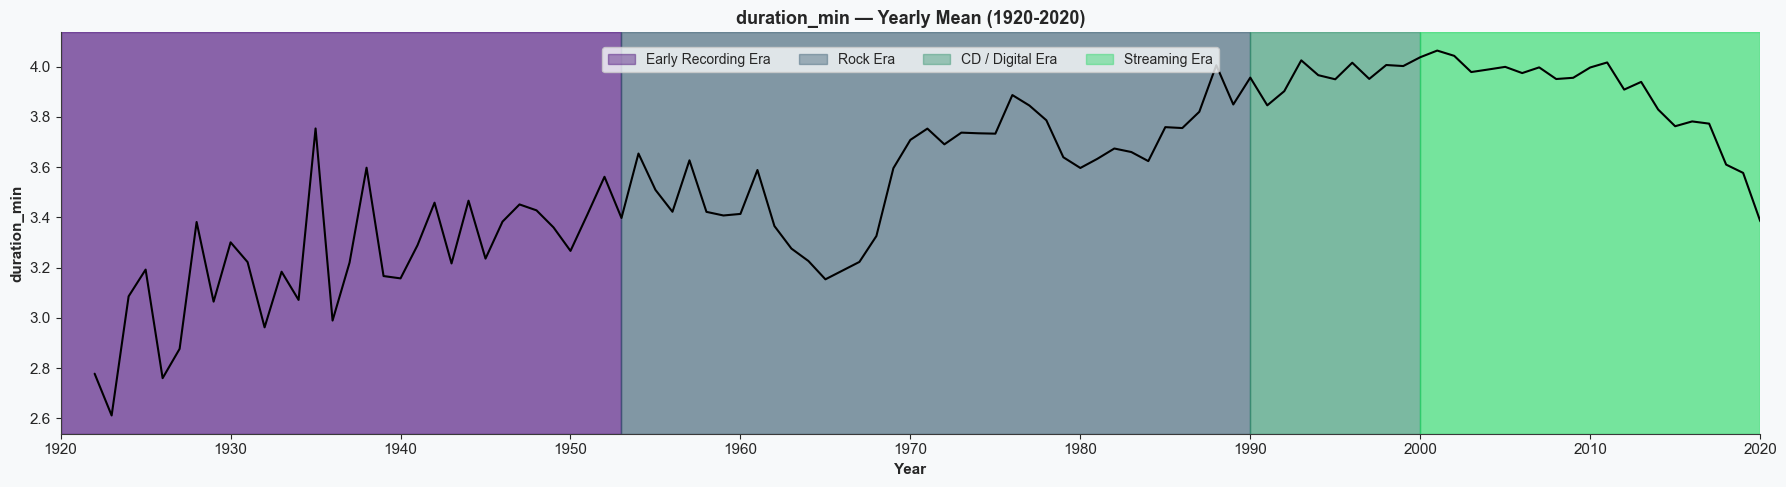

In [38]:
for feature in FEATURES['all']:
    fig, ax = make_fig(figsize=(18, 5))

    shade_eras(ax, alpha=0.6)
    sns.lineplot(data=yearly_means.reset_index(),
                 x='year', y=feature,
                 color='k', linewidth=1.5, ax=ax)

    ax.set_title(f'{feature} — Yearly Mean (1920-2020)', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel(feature)
    ax.set_xlim(1920, 2020)
    ax.set_xticks(range(1920, 2021, 10))

    era_legend(ax=ax, bbox_to_anchor=(0.5, 0.98), ncols=4)

    plt.tight_layout()
    plt.show()

### Key observations from the trend overview

Two clearly opposed groups emerge across the century:

| Trending UP ↑ | Trending DOWN ↓ |
|---|---|
| Loudness | Acousticness |
| Energy | Instrumentalness |
| Danceability | Valence (post-1980) |
| Tempo | |

This mirror pattern is not accidental — the two groups are interconnected,  
and the **Loudness War** appears to be a key driver of these diverging trends.

Almost every feature displays a sharp inflection at the  
**Early Recording → Rock Era boundary (~1953)**, historically grounded in  
the adoption of electric amplification and magnetic tape recording.

> **Liveness exception:** liveness remains flat throughout the entire century  
> (0.18–0.27), confirming it is not a confounding variable in the other trends.  
> It will be excluded from clustering after ablation (see `03_clustering.ipynb`).

---
## 3 · The Loudness War

The Loudness War describes the progressive increase in mastering loudness  
from the 1950s onward, accelerating sharply after 2000 with digital production.  
Louder masters are achieved through **heavy dynamic compression**, with measurable  
consequences on correlated features.

The scatter plots below show yearly means (each dot = one year), colored by era,  
for three feature pairs that reveal the causal structure.

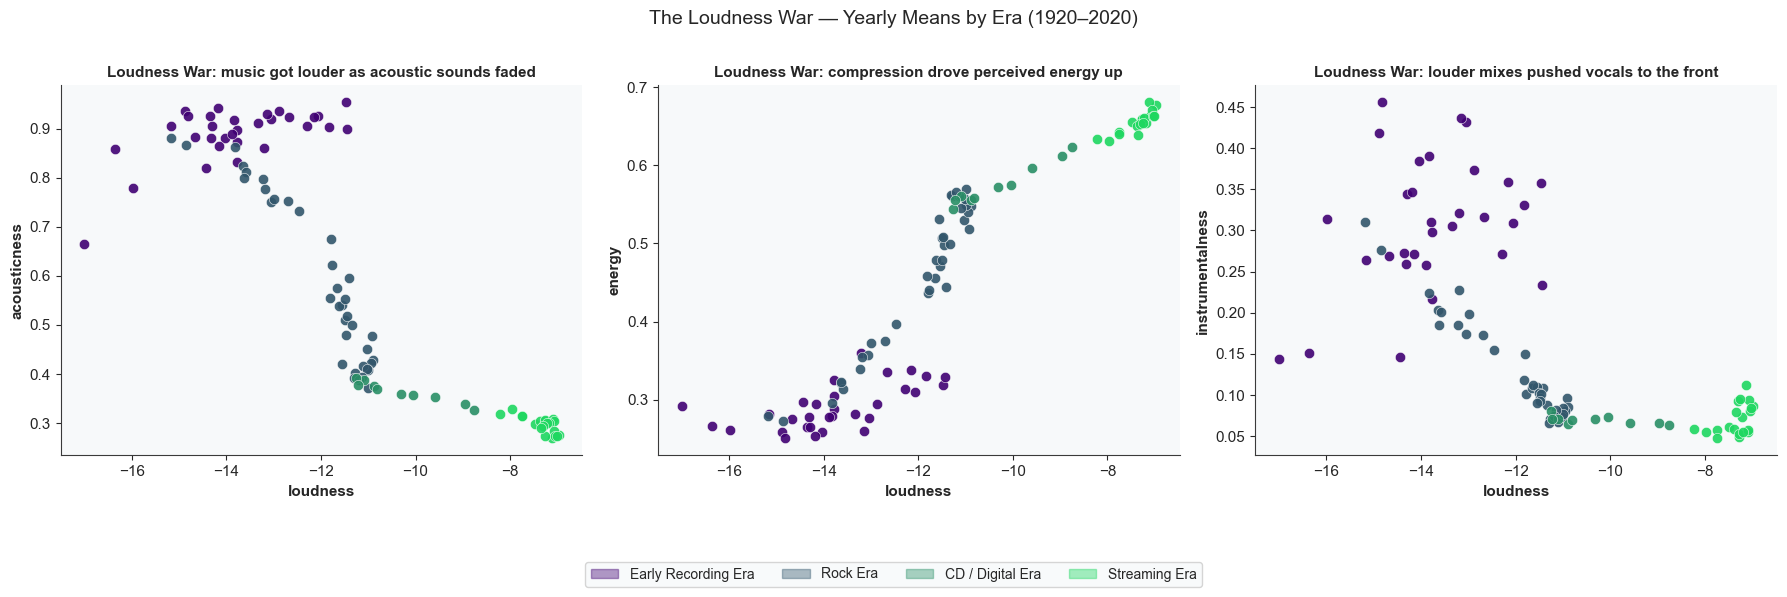

In [39]:
# [STEP 1] - Add era label to yearly_means for color mapping
yearly_means['era'] = yearly_means.index.map(get_era)

# Era color mapping (from ERAS config)
era_color_map = {label: color for _, _, color, label in ERAS}

# Feature pairs to plot: (x, y, subtitle)
pairs = [
    ('loudness', 'acousticness',
     'Loudness War: music got louder as acoustic sounds faded'),
    ('loudness', 'energy',
     'Loudness War: compression drove perceived energy up'),
    ('loudness', 'instrumentalness',
     'Loudness War: louder mixes pushed vocals to the front'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('The Loudness War — Yearly Means by Era (1920–2020)',
             fontsize=14, y=1.01)

for ax, (x_feat, y_feat, subtitle) in zip(axes, pairs):
    for era_label, color in era_color_map.items():
        era_data = yearly_means[yearly_means['era'] == era_label]
        ax.scatter(
            era_data[x_feat], era_data[y_feat],
            color=color, alpha=0.9,
            edgecolors='white', linewidths=0.4,
            s=55, label=era_label
        )
    ax.set_xlabel(x_feat, fontweight='bold')
    ax.set_ylabel(y_feat, fontweight='bold')
    ax.set_title(subtitle, fontsize=11)
    sns.despine(ax=ax)

# Shared era legend below all plots
era_legend(fig=fig, bbox_to_anchor=(0.5, -0.08), ncols=4)

plt.tight_layout()
plt.show()

### Scatter analysis — interpretation

#### Early Recording Era — controlled heterogeneity
The wide dispersion of the earliest era cluster is historically meaningful:  
genuine stylistic diversity (jazz, blues, classical, folk), inconsistent  
recording technology, and small yearly sample sizes all contribute.  
This era represents the *experimentation phase* before the industry converged  
on a dominant production formula.

#### Loudness vs Acousticness — an L-shape, not a line
The relationship is non-linear: acousticness drops steeply as loudness  
increases from −16 to −12 dB, then flattens near 0.3. This is a **floor  
effect** — once electric and digital production took over, acousticness  
could not decrease further regardless of additional loudness gains.

#### Loudness vs Energy — the clearest signal
The most linear of the three. Eras stack almost perfectly along a diagonal,  
providing the strongest visual confirmation of the Loudness War mechanism:  
compression → louder signal → higher perceived energy, consistently across all decades.

#### Loudness vs Instrumentalness — two different stories
The most scattered. Early Recording Era dots sit high on instrumentalness  
across all loudness values — instrumentalness in that era was driven by  
acoustic ensemble music, an entirely **different mechanism** from the modern era,  
where its decline is driven by loud mixes pushing vocals to the front.

---
## 4 · Valence — The Emotional Anomaly

Valence (Spotify's measure of musical positivity) follows a distinct trajectory  
that does not align cleanly with either the loudness-driven group or the acoustic group.  
It deserves isolated analysis.

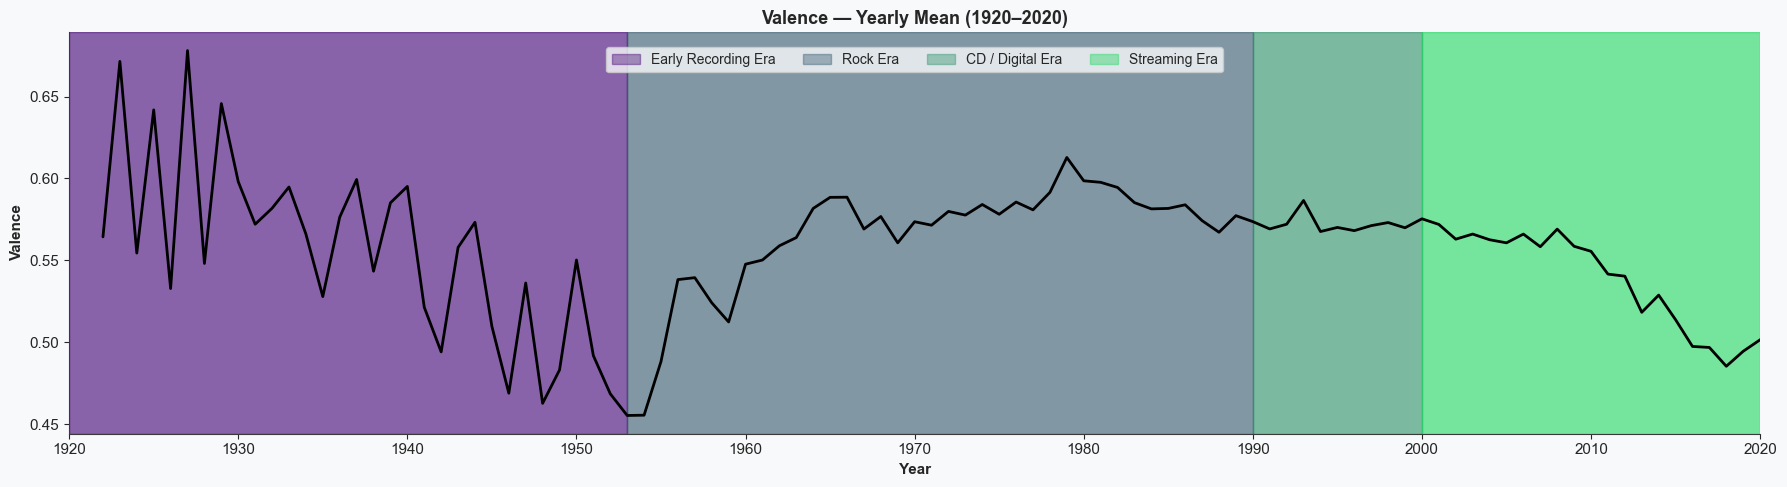

In [40]:
# [STEP 1] - Valence trajectory over time
fig, ax = make_fig(figsize=(18, 5))

shade_eras(ax, alpha=0.6)
sns.lineplot(data=yearly_means.reset_index(),
             x='year', y='valence',
             color='k', linewidth=2, ax=ax)

ax.set_title('Valence — Yearly Mean (1920–2020)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Valence')
ax.set_xlim(1920, 2020)
ax.set_xticks(range(1920, 2021, 10))

era_legend(ax=ax, bbox_to_anchor=(0.5, 0.98), ncols=4)

plt.tight_layout()
plt.show()

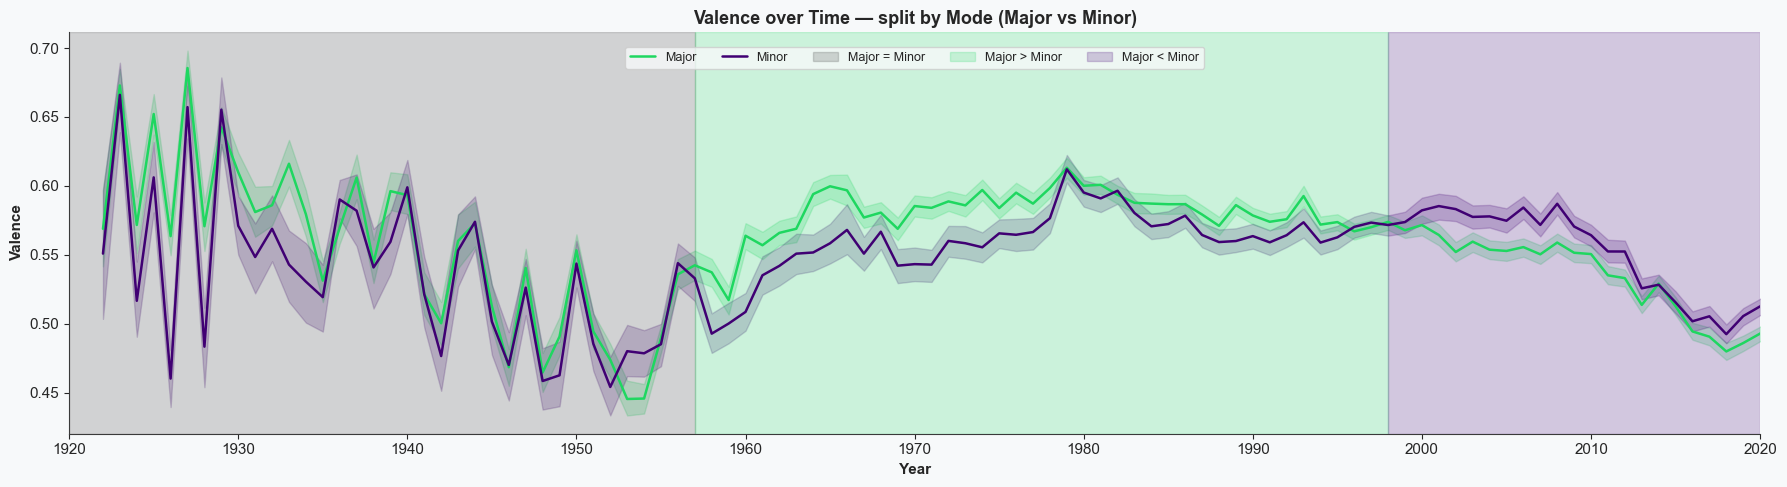

In [41]:
# [STEP 2] - Valence by mode: does the Major/Minor split explain the decline?
fig, ax = make_fig(figsize=(18, 5))

sns.lineplot(
    data=tracks_clean[tracks_clean['year'] >= 1920],
    x='year', y='valence', hue='mode_name',
    palette={'Major': PALETTE['green'], 'Minor': PALETTE['purple']},
    linewidth=1.8, ax=ax
)

# Background periods
ax.axvspan(1920, 1957, color=PALETTE['dark'], alpha=0.2,
           label='Major = Minor')

ax.axvspan(1957, 1998, color=PALETTE['green'], alpha=0.2,
           label='Major > Minor')

ax.axvspan(1998, 2020, color=PALETTE['purple'], alpha=0.2,
           label='Major < Minor')

ax.set_title('Valence over Time — split by Mode (Major vs Minor)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Valence')
ax.set_xlim(1920, 2020)
ax.set_xticks(range(1920, 2021, 10))


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,
          loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncols=6, fontsize=9)

plt.tight_layout()
plt.show()

### Valence findings

**W-shaped trajectory:** high in the 1920s (upbeat dance-oriented music),  
sharp drop toward 1952, recovery through the Rock Era (peaking ~1975–1980),  
then a steady decline through the Streaming Era to its lowest point near 2020.

**Mode does not explain the decline.** When valence is plotted separately  
for Major and Minor tracks, both lines follow *identical trajectories* —  
same W-shape, same inflection points, same streaming-era collapse.  
The gap between them remains small and stable (~0.03–0.05).

This rules out a purely compositional explanation: it is not simply that  
*more minor tracks* are pulling the average down. Even Major-key music  
is becoming emotionally darker over time. The decline is **systemic**,  
likely reflecting genre evolution (rise of hip-hop, dark pop, lo-fi)  
and possibly streaming platform dynamics.

---
## 5 · Mode Distribution Over Time

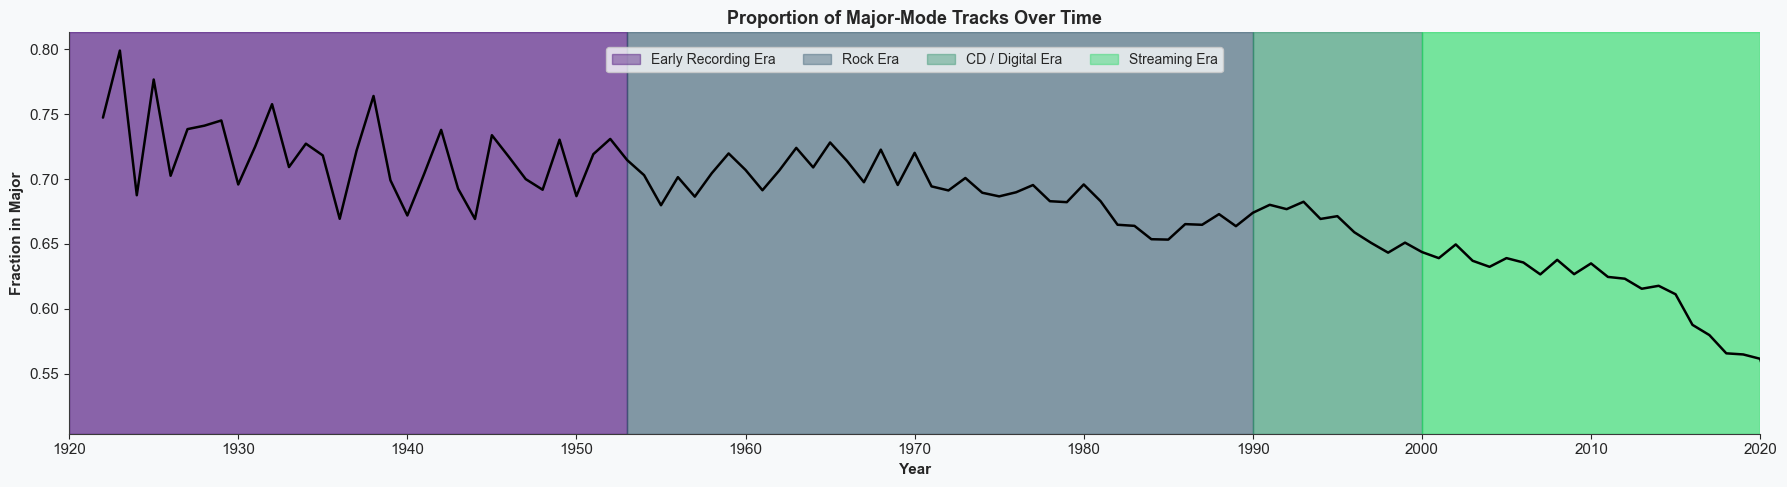

In [42]:
# [STEP 1] - Compute Major frequency per year
major_freq = (
    (tracks_clean['mode_name'] == 'Major')
    .groupby(tracks_clean['year'])
    .mean()
)

fig, ax = make_fig(figsize=(18, 5))

shade_eras(ax, alpha=0.6)
sns.lineplot(data=major_freq, color='k', linewidth=1.8, ax=ax)

ax.set_title('Proportion of Major-Mode Tracks Over Time', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Fraction in Major')
ax.set_xlim(1920, 2020)
ax.set_xticks(range(1920, 2021, 10))


era_legend(ax=ax, bbox_to_anchor=(0.5, 0.98), ncols=4)

plt.tight_layout()
plt.show()

### Mode findings

Major-mode music has been in **continuous decline**: from ~75% in the 1920s  
to ~55% by 2020, with the decline accelerating in the Streaming Era.  
This confirms a long-term compositional shift toward minor-mode music.

However, as shown in Section 4, this shift alone does not explain the valence decline —  
both Major and Minor tracks are becoming darker independently.

---
## 6 · Key Distribution by Decade

In [43]:
# [STEP 1] - Compute key frequency per decade
key_counts  = tracks_clean.groupby(['decade', 'key_name']).size()
key_freq    = key_counts / key_counts.groupby(level='decade').transform('sum')

# Pivot: keys as rows, decades as columns
key_pivot   = key_freq.unstack(level='key_name').T

# Sort rows by mean dominance across decades
key_order   = key_pivot.mean(axis=1).sort_values(ascending=False).index
key_pivot   = key_pivot.loc[key_order]

key_pivot.round(3)

decade,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
key_name,,,,,,,,,,,
C,0.115,0.112,0.116,0.137,0.138,0.136,0.138,0.131,0.122,0.116,0.112
G,0.101,0.112,0.106,0.126,0.129,0.139,0.128,0.136,0.125,0.115,0.099
D,0.072,0.087,0.093,0.095,0.117,0.139,0.127,0.122,0.114,0.098,0.084
F,0.115,0.117,0.109,0.133,0.122,0.094,0.086,0.083,0.081,0.078,0.081
A,0.078,0.082,0.082,0.072,0.100,0.126,0.129,0.124,0.119,0.103,0.082
C♯,0.129,0.093,0.077,0.065,0.053,0.047,0.058,0.065,0.073,0.093,0.122
E,0.047,0.058,0.065,0.056,0.076,0.093,0.092,0.089,0.088,0.079,0.070
A♯,0.078,0.087,0.097,0.088,0.073,0.055,0.055,0.060,0.059,0.063,0.071
G♯,0.079,0.076,0.082,0.086,0.061,0.043,0.045,0.049,0.054,0.064,0.074


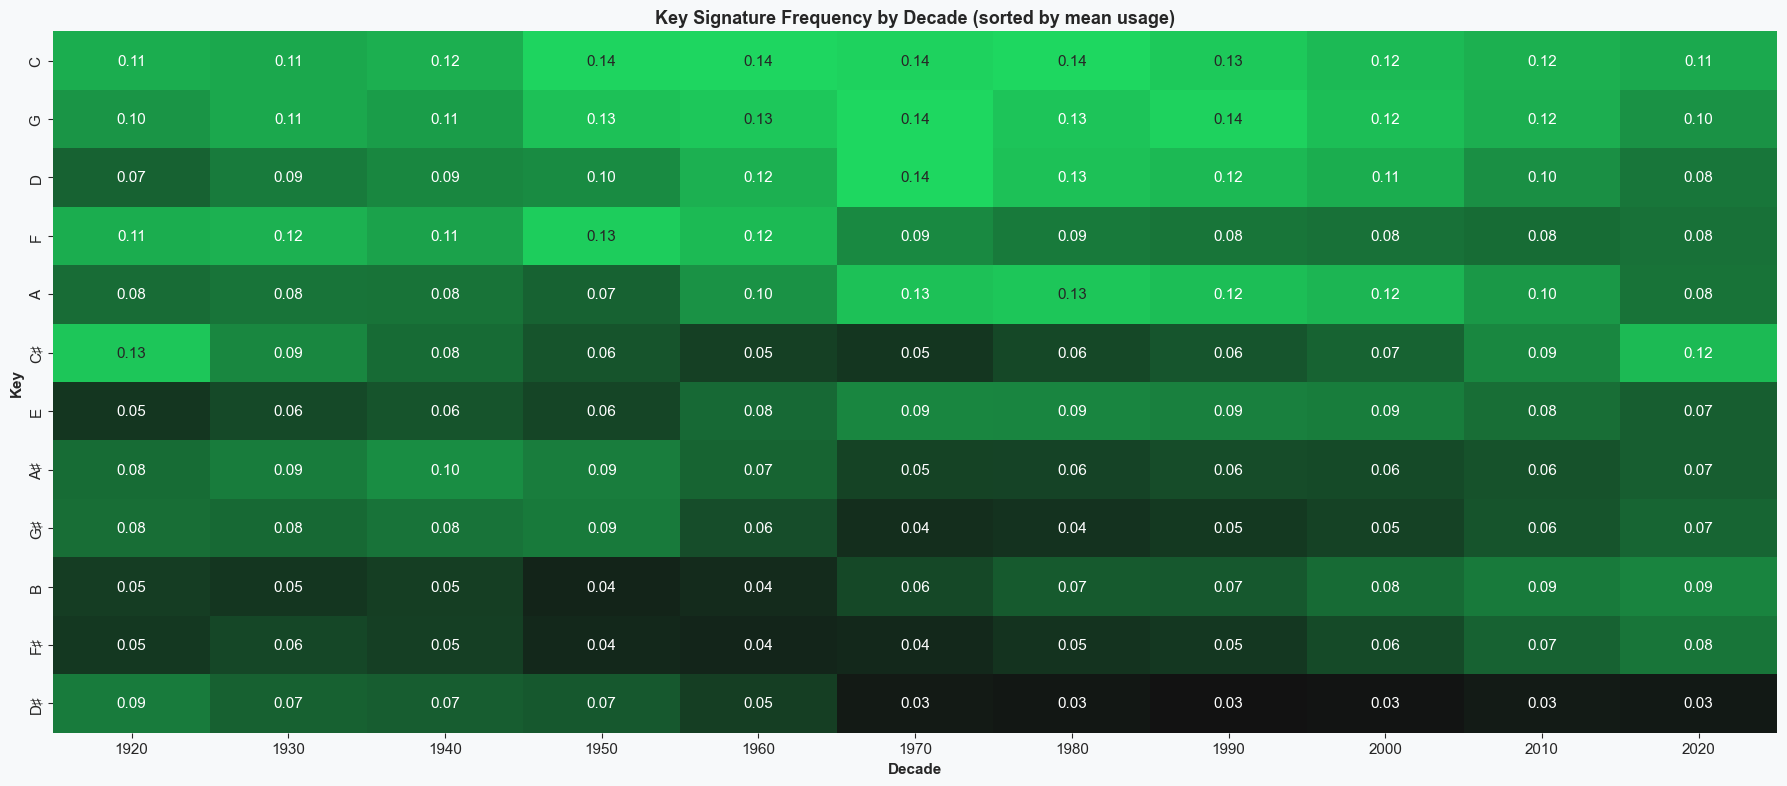

In [44]:
# [STEP 2] - Heatmap: key frequency by decade
fig, ax = make_fig(figsize=(18, 8))

sns.heatmap(
    key_pivot,
    ax=ax,
    annot=True, fmt='.2f',
    cmap='KGr',          # custom cmap from config.py
    cbar=False
)

ax.set_title('Key Signature Frequency by Decade (sorted by mean usage)',
             fontsize=13)
ax.set_ylabel('Key')
ax.set_xlabel('Decade')

plt.tight_layout()
plt.show()

### Key distribution findings

**Natural keys dominate over sharps/flats.** C, G, D and F consistently  
top the heatmap. Natural keys are physically easier to play on guitar  
and piano — the bias toward "guitarist-friendly" keys is structural, not aesthetic.

**C, G, D form a stable dominant triad from the 1950s onward,**  
with proportions consistently between 0.12–0.14. These three keys form  
the gravitational center of Western pop and rock harmony (core of the circle of fifths).

**F declines, A rises — a genre shift in the 1960s–70s.**  
F drops from 0.11–0.13 before the 1960s to 0.08–0.09 afterward,  
while A rises from 0.07 to 0.13. This reflects the rise of electric guitar-driven rock:  
A and E are most natural for guitar (open tuning, power chords),  
while F is notoriously awkward due to the barre chord requirement.

**C# anomaly in the 1920s and resurgence in 2020.**  
The 1920s peak likely reflects brass-heavy jazz and big band arrangements.  
The 2020 resurgence is more plausibly explained by DAW-based production:  
in a digital environment, key has no physical constraint, so producers  
choose freely based on vocal range.

---
## 7 · Summary of Findings

| Dimension | Key finding |
|-----------|-------------|
| **Loudness War** | Loudness increased monotonically from 1950s; likely causal driver of energy↑, acousticness↓, instrumentalness↓ |
| **1953 inflection** | Sharp structural break across almost all features; marks electric amplification and tape recording adoption |
| **Valence** | W-shaped trajectory; decline is systemic (both Major and Minor follow it) — not explained by mode shift |
| **Mode** | Major proportion declined from ~75% to ~55%; accelerated in Streaming Era |
| **Key** | Natural keys dominate due to instrument ergonomics; F→A shift in 1960s tied to electric guitar adoption; C# resurgence in 2020 tied to DAW production |
| **Liveness** | Stable throughout the century — not a confounding variable; excluded from clustering |

> **→ Next notebook:** `03_clustering.ipynb` — unsupervised grouping of tracks  
> by audio profile, with correlation analysis, PCA feature compression, and K-Means.